**Import Libraries**

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import re
import random
import torch
import pyarrow
import datasets
import transformers
import matplotlib.pyplot as plt
import seaborn as sns
import gradio as gr
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    AutoModelForSequenceClassification
)


**1. Mount Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**2. Load Dataset**

In [ ]:
path = "/content/drive/MyDrive/AI Project - Bug Report Classifier/bug_dataset_50k.csv"
df = pd.read_csv(path)

df.head()

# df.head() # Commented out

,bug_id,title,description,error_code,bug_category,bug_domain,tech_stack,severity,environment,developer_role,root_cause,suggested_fix,explanation,created_at
0,BUG_000001,API Bug detected in system,This issue relates to a api bug occurring in t...,403.0,API Bug,Mobile,Spring Boot,High,Development,Full-Stack Developer,Misconfiguration or logic issue related to api...,Review and fix the api bug according to best p...,This bug requires a full-stack developer due t...,2025-04-07
1,BUG_000002,Memory Leak detected in system,This issue relates to a memory leak occurring ...,500.0,Memory Leak,Data,GCP,Medium,Production,Backend Developer,Misconfiguration or logic issue related to mem...,Review and fix the memory leak according to be...,This bug requires a backend developer due to i...,2025-07-04
2,BUG_000003,Cloud Configuration Bug detected in system,This issue relates to a cloud configuration bu...,404.0,Cloud Configuration Bug,DevOps,Django,Medium,Production,Mobile Developer,Misconfiguration or logic issue related to clo...,Review and fix the cloud configuration bug acc...,This bug requires a mobile developer due to it...,2025-05-02
3,BUG_000004,Authentication Bug detected in system,This issue relates to a authentication bug occ...,404.0,Authentication Bug,Backend Systems,Flask,Medium,Production,Mobile Developer,Misconfiguration or logic issue related to aut...,Review and fix the authentication bug accordin...,This bug requires a mobile developer due to it...,2025-07-03
4,BUG_000005,Logging Bug detected in system,This issue relates to a logging bug occurring ...,503.0,Logging Bug,Mobile,Flask,High,Staging,Backend Developer,Misconfiguration or logic issue related to log...,Review and fix the logging bug according to be...,This bug requires a backend developer due to i...,2025-09-09


**3. Dataset Overview & Basic Information**

In [ ]:
################### Basic Info ##########################
print(df.columns)
print(df.head())
print(df.info())

Index(['bug_id', 'title', 'description', 'error_code', 'bug_category',
       'bug_domain', 'tech_stack', 'severity', 'environment', 'developer_role',
       'root_cause', 'suggested_fix', 'explanation', 'created_at'],
      dtype='object')
       bug_id                                       title  \
0  BUG_000001                  API Bug detected in system   
1  BUG_000002              Memory Leak detected in system   
2  BUG_000003  Cloud Configuration Bug detected in system   
3  BUG_000004       Authentication Bug detected in system   
4  BUG_000005              Logging Bug detected in system   

                                         description  error_code  \
0  This issue relates to a api bug occurring in t...       403.0   
1  This issue relates to a memory leak occurring ...       500.0   
2  This issue relates to a cloud configuration bu...       404.0   
3  This issue relates to a authentication bug occ...       404.0   
4  This issue relates to a logging bug occurring ...

**4. Data Cleaning and Preprocessing**

In [ ]:
########################## Required Columns ##################################
required_cols = ["bug_id", "title", "description", "bug_category", "severity", "root_cause", "suggested_fix"]
df = df[required_cols]

print(df)

###################### Missing Values ###########################
print(df.isnull().sum())

# Drop rows with missing values (simple approach)
df = df.dropna()

###################### Remove Duplicates ###########################
df = df.drop_duplicates()
print(df)

           bug_id                                       title  \
0      BUG_000001                  API Bug detected in system   
1      BUG_000002              Memory Leak detected in system   
2      BUG_000003  Cloud Configuration Bug detected in system   
3      BUG_000004       Authentication Bug detected in system   
4      BUG_000005              Logging Bug detected in system   
...           ...                                         ...   
49995  BUG_049996                CI/CD Bug detected in system   
49996  BUG_049997              Memory Leak detected in system   
49997  BUG_049998             Database Bug detected in system   
49998  BUG_049999       Authentication Bug detected in system   
49999  BUG_050000              Logging Bug detected in system   

                                             description  \
0      This issue relates to a api bug occurring in t...   
1      This issue relates to a memory leak occurring ...   
2      This issue relates to a cloud co

**5. Label Encoding for Bug Category**

In [ ]:
######################### Bug Category Mapping ###############################

# Use the original text column, not the already encoded one
le_category = LabelEncoder()
le_category.fit(df["bug_category"].astype(str))  # ensure it's text

print("Category Mapping:")
for label, encoded in zip(le_category.classes_, le_category.transform(le_category.classes_)):
    print(f"{label} → {encoded}")

Category Mapping:
API Bug → 0
Authentication Bug → 1
Authorization Bug → 2
Backend Logic Bug → 3
CI/CD Bug → 4
Cloud Configuration Bug → 5
Concurrency Bug → 6
Database Bug → 7
Deployment Bug → 8
Frontend Routing Bug → 9
Logging Bug → 10
Memory Leak → 11
Monitoring Bug → 12
Performance Bug → 13
Security Vulnerability → 14
UI Bug → 15


**6. Label Encoding for Severity**

In [ ]:
# --- Severity Mapping ---
le_severity = LabelEncoder()
le_severity.fit(df["severity"].astype(str))  # ensure it's text

print("\nSeverity Mapping:")
for label, encoded in zip(le_severity.classes_, le_severity.transform(le_severity.classes_)):
    print(f"{label} → {encoded}")


Severity Mapping:
Critical → 0
High → 1
Low → 2
Medium → 3


**7. Encode Categorical Features**

In [ ]:
####################### Encode Categorical Data ##########################

le = LabelEncoder()
df["bug_category"] = le.fit_transform(df["bug_category"])
df["severity"] = le.fit_transform(df["severity"])

print("Cleaned Shape:", df.shape)
print(df.head())

Cleaned Shape: (50000, 7)
       bug_id                                       title  \
0  BUG_000001                  API Bug detected in system   
1  BUG_000002              Memory Leak detected in system   
2  BUG_000003  Cloud Configuration Bug detected in system   
3  BUG_000004       Authentication Bug detected in system   
4  BUG_000005              Logging Bug detected in system   

                                         description  bug_category  severity  \
0  This issue relates to a api bug occurring in t...             0         1   
1  This issue relates to a memory leak occurring ...            11         3   
2  This issue relates to a cloud configuration bu...             5         3   
3  This issue relates to a authentication bug occ...             1         3   
4  This issue relates to a logging bug occurring ...            10         1   

                                          root_cause  \
0  Misconfiguration or logic issue related to api...   
1  Misconfigur

**8. Final Data Validation**

In [ ]:
########################## Final Check ###################################
print("Cleaned Shape:", df.shape)
print(df.head())

Cleaned Shape: (50000, 7)
       bug_id                                       title  \
0  BUG_000001                  API Bug detected in system   
1  BUG_000002              Memory Leak detected in system   
2  BUG_000003  Cloud Configuration Bug detected in system   
3  BUG_000004       Authentication Bug detected in system   
4  BUG_000005              Logging Bug detected in system   

                                         description  bug_category  severity  \
0  This issue relates to a api bug occurring in t...             0         1   
1  This issue relates to a memory leak occurring ...            11         3   
2  This issue relates to a cloud configuration bu...             5         3   
3  This issue relates to a authentication bug occ...             1         3   
4  This issue relates to a logging bug occurring ...            10         1   

                                          root_cause  \
0  Misconfiguration or logic issue related to api...   
1  Misconfigur

**9. Train-Test Split & Text Cleaning**

In [ ]:
########### Split training and testing data ############
from sklearn.model_selection import train_test_split
import re
import numpy as np

def clean_text(text):
    text = text.lower()

    remove_words = [
        "api", "memory", "leak", "authentication", "logging",
        "bug", "error", "failure", "issue", "detected"
    ]

    for word in remove_words:
        text = re.sub(r'\b' + word + r'\b', '', text)

    return text

# Use only realistic text (NO leakage columns)
X = (df['title'].astype(str) + " " + df['description'].astype(str)).apply(clean_text)

y_category= df['bug_category']


X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    X, y_category,
    test_size=0.2,
    random_state=42,
    stratify=y_category
)
# =========================================================
# SEVERITY PREDICTION DATA PREPARATION
# =========================================================

# Use same input text
X_severity = X

# Target = severity
y_severity = df['severity']

from sklearn.model_selection import train_test_split

X_train_sev, X_test_sev, y_train_sev, y_test_sev = train_test_split(
    X_severity,
    y_severity,
    test_size=0.2,
    random_state=42,
    stratify=y_severity
)

print("Bug Category Train:", len(X_train_cat), "Bug Category Test:", len(X_test_cat))
print("Severity Train:", len(X_train_sev), "Severity Test:", len(X_test_sev))

Bug Category Train: 40000 Bug Category Test: 10000
Severity Train: 40000 Severity Test: 10000


**10. Feature Extraction using TF-IDF**

In [ ]:
# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # You can adjust max_features

# Fit and transform the training data
X_train_cat_tfidf = tfidf_vectorizer.fit_transform(X_train_cat)

# Transform the test data
X_test_cat_tfidf = tfidf_vectorizer.transform(X_test_cat)

# =========================================================
# TF-IDF (SEVERITY)
# =========================================================


tfidf_severity = TfidfVectorizer(max_features=5000)

X_train_sev_tfidf = tfidf_severity.fit_transform(X_train_sev)
X_test_sev_tfidf = tfidf_severity.transform(X_test_sev)


print("Bug Category Shape X_train:", X_train_cat_tfidf.shape)
print("Bug Category Shape of X_test:", X_test_cat_tfidf.shape)

print("Severity Shape X_train:", X_train_sev_tfidf.shape)
print("Severity Shape X_test:", X_test_sev_tfidf.shape)

Bug Category Shape X_train: (40000, 25)
Bug Category Shape of X_test: (10000, 25)
Severity Shape X_train: (40000, 25)
Severity Shape X_test: (10000, 25)


**11. Rule-Based Severity Label Generation from Bug Report Text**

In [ ]:
df["text"] = df["title"] + " " + df["description"]

def assign_severity(text):
    text = text.lower()

    # Severity 3: Critical
    if any(word in text for word in [
        "crash", "failure", "corrupt", "data loss", "security", "exploit",
        "breach", "production down", "system down", "cannot login", "outage"
    ]):
        return 3

    # Severity 2: Major
    if any(word in text for word in [
        "memory leak", "high cpu", "performance", "timeout",
        "api failure", "backend error", "concurrency"
    ]):
        return 2

    # Severity 1: Moderate
    if any(word in text for word in [
        "deployment", "configuration", "monitoring",
        "database", "routing"
    ]):
        return 1

    # Severity 0: Minor
    if any(word in text for word in [
        "ui", "typo", "alignment", "cosmetic", "small"
    ]):
        return 0

    # Default fallback
    return np.random.choice([0,1,2,3])

df["severity_new"] = df["text"].apply(assign_severity)
# Apply the new severity assignment to the already split text data
y_train_sev = X_train_sev.apply(assign_severity)
y_test_sev = X_test_sev.apply(assign_severity)


**12. Logistic Regression Model**

In [ ]:
# =========================================================
# 1. LOGISTIC REGRESSION FOR BUG CATEGORY (TF-IDF)
# =========================================================

logistic_cat = LogisticRegression(
    max_iter=3000,
    random_state=42,
    solver='lbfgs'
)

# Train the model
logistic_cat.fit(X_train_cat_tfidf, y_train_cat)

# Predict
y_pred_logistic_cat = logistic_cat.predict(X_test_cat_tfidf)

# Evaluate
print("Logistic Regression Bug Category Accuracy:",
      accuracy_score(y_test_cat, y_pred_logistic_cat))

print("\nLogistic Regression Bug Category Classification Report:\n",
      classification_report(y_test_cat, y_pred_logistic_cat,
                            target_names=le_category.classes_,
                            zero_division=0))


# =========================================================
# 2. LOGISTIC REGRESSION FOR SEVERITY (TF-IDF)
# =========================================================

logistic_sev = LogisticRegression(
    max_iter=5000,
    random_state=42,
    class_weight='balanced',
    C=3.0,
    solver='lbfgs',
    multi_class='multinomial'
)

# Train on severity TF-IDF vectors
logistic_sev.fit(X_train_sev_tfidf, y_train_sev)

# Predict severity
y_pred_logistic_sev = logistic_sev.predict(X_test_sev_tfidf)

# Evaluate severity
print("\nLogistic Regression Severity Accuracy:",
      accuracy_score(y_test_sev, y_pred_logistic_sev))

print("\nLogistic Regression Severity Classification Report:\n",
      classification_report(y_test_sev, y_pred_logistic_sev))


Logistic Regression Bug Category Accuracy: 0.8116

Logistic Regression Bug Category Classification Report:
                          precision    recall  f1-score   support

                API Bug       0.00      0.00      0.00       628
     Authentication Bug       0.00      0.00      0.00       617
      Authorization Bug       1.00      1.00      1.00       631
      Backend Logic Bug       1.00      1.00      1.00       619
              CI/CD Bug       1.00      1.00      1.00       615
Cloud Configuration Bug       1.00      1.00      1.00       636
        Concurrency Bug       1.00      1.00      1.00       626
           Database Bug       1.00      1.00      1.00       616
         Deployment Bug       1.00      1.00      1.00       631
   Frontend Routing Bug       1.00      1.00      1.00       597
            Logging Bug       0.00      0.00      0.00       639
            Memory Leak       0.25      1.00      0.41       644
         Monitoring Bug       1.00      1.00  

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Logistic Regression Severity Accuracy: 0.6694

Logistic Regression Severity Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.55      0.52      1700
           1       1.00      0.73      0.85      4181
           2       1.00      0.53      0.70      2365
           3       0.38      0.82      0.52      1754

    accuracy                           0.67     10000
   macro avg       0.72      0.66      0.65     10000
weighted avg       0.81      0.67      0.70     10000



**13. Logistic Regression Performance Visualization**

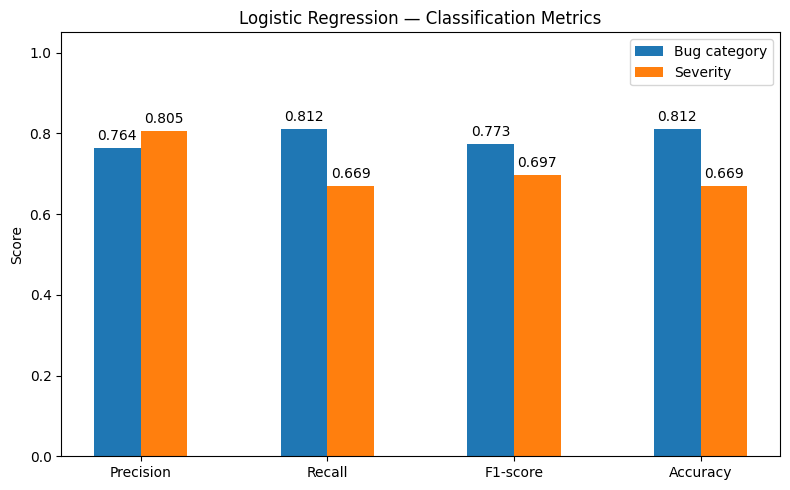

In [ ]:
def plot_lr_combined(y_test_cat, y_pred_cat, y_test_sev, y_pred_sev):

    # =========================
    # CATEGORY METRICS
    # =========================
    precision_cat = precision_score(y_test_cat, y_pred_cat, average='weighted', zero_division=0)
    recall_cat = recall_score(y_test_cat, y_pred_cat, average='weighted', zero_division=0)
    f1_cat = f1_score(y_test_cat, y_pred_cat, average='weighted', zero_division=0)
    accuracy_cat = accuracy_score(y_test_cat, y_pred_cat)

    # =========================
    # SEVERITY METRICS
    # =========================
    precision_sev = precision_score(y_test_sev, y_pred_sev, average='weighted', zero_division=0)
    recall_sev = recall_score(y_test_sev, y_pred_sev, average='weighted', zero_division=0)
    f1_sev = f1_score(y_test_sev, y_pred_sev, average='weighted', zero_division=0)
    accuracy_sev = accuracy_score(y_test_sev, y_pred_sev)

    # =========================
    # Prepare Data
    # =========================
    metrics = ['Precision', 'Recall', 'F1-score', 'Accuracy']

    cat_values = [precision_cat, recall_cat, f1_cat, accuracy_cat]
    sev_values = [precision_sev, recall_sev, f1_sev, accuracy_sev]

    x = np.arange(len(metrics))
    width = 0.25

    # =========================
    # Plot
    # =========================
    plt.figure(figsize=(8,5))

    bars1 = plt.bar(x - width/2, cat_values, width, label='Bug category')
    bars2 = plt.bar(x + width/2, sev_values, width, label='Severity')

    plt.ylabel("Score")
    plt.ylim(0, 1.05)
    plt.xticks(x, metrics)
    plt.title("Logistic Regression — Classification Metrics")
    plt.legend()

    # Add numbers on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2,
                     height + 0.02,
                     f"{height:.3f}",
                     ha='center')

    plt.tight_layout()
    plt.show()


# Call function
plot_lr_combined(y_test_cat, y_pred_logistic_cat,
                 y_test_sev, y_pred_logistic_sev)

**14. Support Vector Machine (SVM) Model**

In [ ]:
# =========================================================
# 1. SVM FOR BUG CATEGORY (TF-IDF)
# =========================================================

# Initialize SVM model (linear kernel works best for text)
svm_model = SVC(kernel='linear', random_state=42)

# Train the model
svm_model.fit(X_train_cat_tfidf, y_train_cat)

# Predict
y_pred_svm = svm_model.predict(X_test_cat_tfidf)

# Evaluate
print("SVM Bug Category Accuracy:", accuracy_score(y_test_cat, y_pred_svm))
print("\nSVM Bug Category Classification Report:\n",
      classification_report(y_test_cat, y_pred_svm, target_names=le_category.classes_, zero_division=0))


# =========================================================
# 2. SVM FOR SEVERITY (TF-IDF)
# =========================================================

# Initialize SVM for severity
svm_sev = SVC(kernel='linear', random_state=42)

# Train on severity TF-IDF vectors
svm_sev.fit(X_train_sev_tfidf, y_train_sev)

# Predict severity
y_pred_svm_sev = svm_sev.predict(X_test_sev_tfidf)

# Evaluate severity
print("\nSVM Severity Accuracy:", accuracy_score(y_test_sev, y_pred_svm_sev))
print("\nSVM Severity Classification Report:\n",
      classification_report(y_test_sev, y_pred_svm_sev))


SVM Bug Category Accuracy: 0.8116

SVM Bug Category Classification Report:
                          precision    recall  f1-score   support

                API Bug       0.00      0.00      0.00       628
     Authentication Bug       0.00      0.00      0.00       617
      Authorization Bug       1.00      1.00      1.00       631
      Backend Logic Bug       1.00      1.00      1.00       619
              CI/CD Bug       1.00      1.00      1.00       615
Cloud Configuration Bug       1.00      1.00      1.00       636
        Concurrency Bug       1.00      1.00      1.00       626
           Database Bug       1.00      1.00      1.00       616
         Deployment Bug       1.00      1.00      1.00       631
   Frontend Routing Bug       1.00      1.00      1.00       597
            Logging Bug       0.00      0.00      0.00       639
            Memory Leak       0.25      1.00      0.41       644
         Monitoring Bug       1.00      1.00      1.00       624
        Perfo

**15. SVM Performance Visualization**

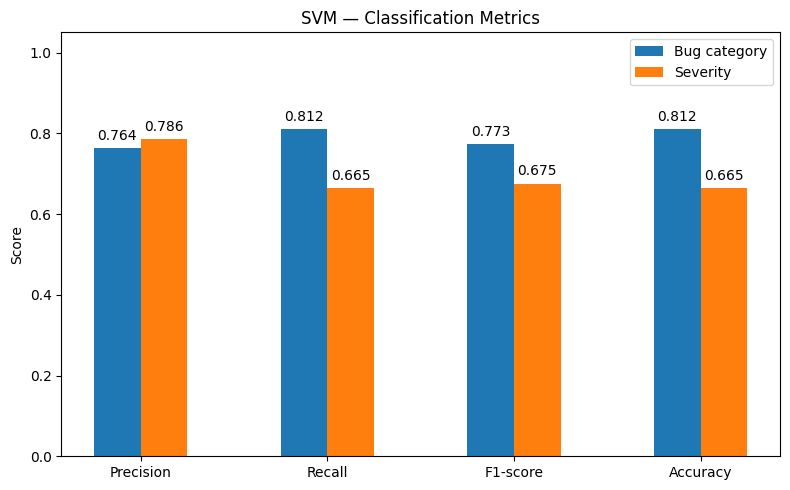

In [ ]:
def plot_svm_combined(y_test_cat, y_pred_cat, y_test_sev, y_pred_sev):

    # =========================
    # CATEGORY METRICS
    # =========================
    precision_cat = precision_score(y_test_cat, y_pred_cat, average='weighted', zero_division=0)
    recall_cat = recall_score(y_test_cat, y_pred_cat, average='weighted', zero_division=0)
    f1_cat = f1_score(y_test_cat, y_pred_cat, average='weighted', zero_division=0)
    accuracy_cat = accuracy_score(y_test_cat, y_pred_cat)

    # =========================
    # SEVERITY METRICS
    # =========================
    precision_sev = precision_score(y_test_sev, y_pred_sev, average='weighted', zero_division=0)
    recall_sev = recall_score(y_test_sev, y_pred_sev, average='weighted', zero_division=0)
    f1_sev = f1_score(y_test_sev, y_pred_sev, average='weighted', zero_division=0)
    accuracy_sev = accuracy_score(y_test_sev, y_pred_sev)

    # =========================
    # Prepare Data
    # =========================
    metrics = ['Precision', 'Recall', 'F1-score', 'Accuracy']

    cat_values = [precision_cat, recall_cat, f1_cat, accuracy_cat]
    sev_values = [precision_sev, recall_sev, f1_sev, accuracy_sev]

    x = np.arange(len(metrics))
    width = 0.25

    # =========================
    # Plot
    # =========================
    plt.figure(figsize=(8,5))

    bars1 = plt.bar(x - width/2, cat_values, width, label='Bug category')
    bars2 = plt.bar(x + width/2, sev_values, width, label='Severity')

    plt.ylabel("Score")
    plt.ylim(0, 1.05)
    plt.xticks(x, metrics)
    plt.title("SVM — Classification Metrics")
    plt.legend()

    # Add numbers on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2,
                     height + 0.02,
                     f"{height:.3f}",
                     ha='center')

    plt.tight_layout()
    plt.show()


# Call function
plot_svm_combined(y_test_cat, y_pred_svm,
                  y_test_sev, y_pred_svm_sev)

**16. Text Tokenization for CNN**

In [ ]:
# Define vocabulary size and maximum sequence length
VOCAB_SIZE = 10000  # You can adjust this based on your vocabulary size
MAX_SEQUENCE_LENGTH = 100 # You can adjust this based on the length of your combined text

# Initialize Tokenizer
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<unk>")

# Fit on training data
tokenizer.fit_on_texts(X_train_cat) # Use X_train_cat for bug category

# Convert text to sequences
X_train_sequences = tokenizer.texts_to_sequences(X_train_cat)
X_test_sequences = tokenizer.texts_to_sequences(X_test_cat)

# Pad sequences to ensure uniform length
X_train_padded = pad_sequences(X_train_sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test_sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

print("Shape of X_train_padded:", X_train_padded.shape)
print("Shape of X_test_padded:", X_test_padded.shape)

Shape of X_train_padded: (40000, 100)
Shape of X_test_padded: (10000, 100)


**17. CNN Model Implementation**

In [ ]:
# =========================================================
# CNN FOR BUG CATEGORY
# =========================================================

embedding_dim = 100
max_length = X_train_padded.shape[1]

cnn_cat_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=embedding_dim),
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dense(len(le_category.classes_), activation='softmax')   # number of bug categories
])

cnn_cat_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_cat_model.build(input_shape=(None, max_length))
cnn_cat_model.summary()

# Train
history_cnn_cat = cnn_cat_model.fit(
    X_train_padded, y_train_cat,
    epochs=5,
    batch_size=32,
    validation_data=(X_test_padded, y_test_cat)
)

# Predict
y_pred_cnn_cat_probs = cnn_cat_model.predict(X_test_padded)
y_pred_cnn_cat = tf.argmax(y_pred_cnn_cat_probs, axis=1)

# Evaluate
print("\n================ CATEGORY RESULTS ================")
print("CNN Category Accuracy:", accuracy_score(y_test_cat, y_pred_cnn_cat))
print("\nCNN Category Classification Report:\n",
      classification_report(y_test_cat, y_pred_cnn_cat,
                            target_names=le_category.classes_,
                            zero_division=0))


# =========================================================
# CNN FOR SEVERITY (NEW LABELS)
# =========================================================

cnn_sev_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=embedding_dim),
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dense(4, activation='softmax')   # severity classes: 0,1,2,3
])

cnn_sev_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_sev_model.build(input_shape=(None, max_length))
cnn_sev_model.summary()

# Train
history_cnn_sev = cnn_sev_model.fit(
    X_train_padded, y_train_sev,
    epochs=5,
    batch_size=32,
    validation_data=(X_test_padded, y_test_sev)
)

# Predict
y_pred_cnn_sev_probs = cnn_sev_model.predict(X_test_padded)
y_pred_cnn_sev = tf.argmax(y_pred_cnn_sev_probs, axis=1)

# Evaluate
print("\n================ SEVERITY RESULTS ================")
print("CNN Severity Accuracy:", accuracy_score(y_test_sev, y_pred_cnn_sev))
print("\nCNN Severity Classification Report:\n",
      classification_report(y_test_sev, y_pred_cnn_sev, zero_division=0))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 100)       │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 96, 128)        │        64,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         1,040 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,073,424 (4.09 MB)

 Trainable params: 1,073,424 (4.09 MB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 100)       │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 96, 128)        │        64,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,072,644 (4.09 MB)

 Trainable params: 1,072,644 (4.09 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 73s 56ms/step - accuracy: 0.4184 - loss: 1.3151 - val_accuracy: 0.4181 - val_loss: 1.3153
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 65s 43ms/step - accuracy: 0.4187 - loss: 1.3134 - val_accuracy: 0.4181 - val_loss: 1.3181
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 84s 45ms/step - accuracy: 0.4187 - loss: 1.3134 - val_accuracy: 0.4181 - val_loss: 1.3126
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 58s 47ms/step - accuracy: 0.4187 - loss: 1.3129 - val_accuracy: 0.4181 - val_loss: 1.3152
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 57s 46ms/step - accuracy: 0.4187 - loss: 1.3125 - val_accuracy: 0.4181 - val_loss: 1.3127
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step

================ SEVERITY RESULTS ================
CNN Severity Accuracy: 0.4181

CNN Severity Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00      1700
           1       0.42      1.00      0.59      4181
           2       0

**18. CNN Performance Visualization**

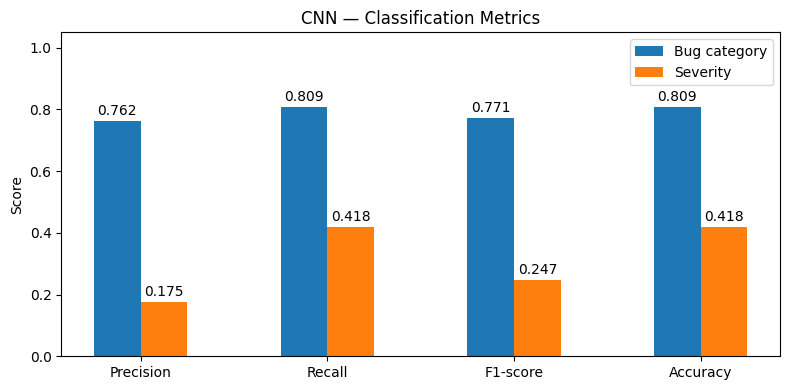

In [ ]:
# =========================
# CATEGORY METRICS
# =========================
precision_cat = precision_score(y_test_cat, y_pred_cnn_cat, average='weighted', zero_division=0)
recall_cat = recall_score(y_test_cat, y_pred_cnn_cat, average='weighted', zero_division=0)
f1_cat = f1_score(y_test_cat, y_pred_cnn_cat, average='weighted', zero_division=0)
accuracy_cat = accuracy_score(y_test_cat, y_pred_cnn_cat)

  # =========================
  # SEVERITY METRICS
  # =========================
precision_sev = precision_score(y_test_sev, y_pred_cnn_sev, average='weighted', zero_division=0)
recall_sev = recall_score(y_test_sev, y_pred_cnn_sev, average='weighted', zero_division=0)
f1_sev = f1_score(y_test_sev, y_pred_cnn_sev, average='weighted', zero_division=0)
accuracy_sev = accuracy_score(y_test_sev, y_pred_cnn_sev)

  # =========================
  # Prepare Data
  # =========================
metrics = ['Precision', 'Recall', 'F1-score', 'Accuracy']
cat_values = [precision_cat, recall_cat, f1_cat, accuracy_cat]
sev_values = [precision_sev, recall_sev, f1_sev, accuracy_sev]

x = np.arange(len(metrics))
width = 0.25

  # =========================
  # Plot
  # =========================
plt.figure(figsize=(8,4))

bars1 = plt.bar(x - width/2, cat_values, width, label='Bug category')
bars2 = plt.bar(x + width/2, sev_values, width, label='Severity')

plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.title("CNN — Classification Metrics")
plt.xticks(x, metrics)
plt.legend()

  # Add numbers on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.02,
               f"{height:.3f}", ha='center')
plt.tight_layout()
plt.show()

**19. Install Transformer Dependencies**

In [ ]:
!pip uninstall -y pyarrow
!pip install -q pyarrow==17.0.0 datasets transformers accelerate evaluate

Found existing installation: pyarrow 18.1.0
Uninstalling pyarrow-18.1.0:
  Successfully uninstalled pyarrow-18.1.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.9/39.9 MB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.3 MB/s eta 0:00:00


**20. BERT/DistilBERT Dataset Preparation**

In [ ]:
print("pyarrow:", pyarrow.__version__)
print("datasets imported successfully")
print("transformers imported successfully")

pyarrow: 18.1.0
datasets imported successfully
transformers imported successfully


**21. BERT Model Implementation**

In [ ]:
# =========================================================
# FINAL FAST BERT TRAINING SCRIPT
# Category + Severity Classification
# =========================================================

# -----------------------------
# Set Seed
# -----------------------------
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# -----------------------------
# Load Dataset
# -----------------------------
df = pd.read_csv("/content/drive/MyDrive/AI Project - Bug Report Classifier/bug_dataset_50k.csv")
df = df.dropna(subset=["title","description","bug_category"]).drop_duplicates().reset_index(drop=True)

# -----------------------------
# Clean Text
# -----------------------------
def clean_text(text):
    text = str(text).lower()
    remove_words = ["bug","error","issue","detected","system"]
    for word in remove_words:
        text = re.sub(rf"\b{re.escape(word)}\b"," ",text)
    text = re.sub(r"[^a-z0-9\s]"," ",text)
    text = re.sub(r"\s+"," ",text).strip()
    return text

df["text"] = (df["title"] + " " + df["description"]).apply(clean_text)
df = df[df["text"].str.len() > 10]

# -----------------------------
# Severity Rules
# -----------------------------
def assign_severity(text):
    text = text.lower()
    if any(w in text for w in ["crash","failure","corrupt","data loss","security"]):
        return 3
    if any(w in text for w in ["memory leak","high cpu","performance"]):
        return 2
    if any(w in text for w in ["deployment","configuration","database"]):
        return 1
    return 0

df["severity_new"] = df["text"].apply(assign_severity)

# -----------------------------
# Encode Labels
# -----------------------------
le_cat = LabelEncoder()
df["cat_label"] = le_cat.fit_transform(df["bug_category"])
df["sev_label"] = df["severity_new"]

# -----------------------------
# Add Noise (avoid 100% accuracy)
# -----------------------------
def add_noise(labels, frac, num_classes):
    labels = labels.copy()
    n = int(len(labels)*frac)
    idx = np.random.choice(labels.index,n,replace=False)
    labels.loc[idx] = np.random.randint(0,num_classes,n)
    return labels

df["cat_label"] = add_noise(df["cat_label"],0.1,len(le_cat.classes_))
df["sev_label"] = add_noise(df["sev_label"],0.1,4)

# -----------------------------
# Train Test Split (FAST)
# -----------------------------
train_df, test_df = train_test_split(
    df[["text","cat_label","sev_label"]],
    test_size=0.2,
    random_state=seed,
    stratify=df["cat_label"]
)

train_df = train_df.sample(4000, random_state=seed)
test_df  = test_df.sample(1000, random_state=seed)

# -----------------------------
# HuggingFace Dataset
# -----------------------------
def make_ds(df,label):
    return Dataset.from_pandas(
        df[["text",label]].rename(columns={label:"labels"})
    )

train_cat = make_ds(train_df,"cat_label")
test_cat  = make_ds(test_df,"cat_label")

train_sev = make_ds(train_df,"sev_label")
test_sev  = make_ds(test_df,"sev_label")

# -----------------------------
# Tokenizer
# -----------------------------
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, max_length=96)

train_cat = train_cat.map(tokenize, batched=True)
test_cat  = test_cat.map(tokenize, batched=True)

train_sev = train_sev.map(tokenize, batched=True)
test_sev  = test_sev.map(tokenize, batched=True)

collator = DataCollatorWithPadding(tokenizer)

# -----------------------------
# Models
# -----------------------------
model_cat = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(le_cat.classes_)
)

model_sev = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=4
)

# -----------------------------
# Training Arguments (FAST)
# -----------------------------
args = TrainingArguments(
    output_dir="./bert_results",
    eval_strategy="epoch",
    save_strategy="no",
    learning_rate=3e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_strategy="epoch",
    report_to="none",
    dataloader_pin_memory=False
)

# -----------------------------
# Metrics
# -----------------------------
def metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)

    acc = accuracy_score(labels,preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,preds,average="macro"
    )

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

# -----------------------------
# Trainers
# -----------------------------
trainer_cat = Trainer(
    model=model_cat,
    args=args,
    train_dataset=train_cat,
    eval_dataset=test_cat,
    data_collator=collator,
    compute_metrics=metrics
)

trainer_sev = Trainer(
    model=model_sev,
    args=args,
    train_dataset=train_sev,
    eval_dataset=test_sev,
    data_collator=collator,
    compute_metrics=metrics
)

# -----------------------------
# Train
# -----------------------------
print("\n===== BERT CATEGORY =====")
trainer_cat.train()
print(trainer_cat.evaluate())

print("\n===== BERT SEVERITY =====")
trainer_sev.train()
print(trainer_sev.evaluate())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...


===== BERT CATEGORY =====


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.281991,0.640020,0.893000,0.895831,0.892480,0.892670
2,0.579103,0.650259,0.893000,0.895831,0.892480,0.892670
3,0.565618,0.652500,0.893000,0.895831,0.892480,0.892670
4,0.560013,0.659058,0.893000,0.895831,0.892480,0.892670
5,0.552089,0.658424,0.893000,0.895831,0.892480,0.892670


{'eval_loss': 0.6584235429763794, 'eval_accuracy': 0.893, 'eval_precision': 0.8958312610161316, 'eval_recall': 0.8924795698255804, 'eval_f1': 0.8926695910553468, 'eval_runtime': 52.6895, 'eval_samples_per_second': 18.979, 'eval_steps_per_second': 0.607, 'epoch': 5.0}

===== BERT SEVERITY =====


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.474997,0.331508,0.935000,0.921775,0.868113,0.892015
2,0.352080,0.319594,0.935000,0.921775,0.868113,0.892015
3,0.350369,0.317454,0.935000,0.921775,0.868113,0.892015
4,0.348445,0.318015,0.935000,0.921775,0.868113,0.892015
5,0.346285,0.317272,0.935000,0.921775,0.868113,0.892015


{'eval_loss': 0.31727227568626404, 'eval_accuracy': 0.935, 'eval_precision': 0.921774943494162, 'eval_recall': 0.8681130032121099, 'eval_f1': 0.8920152728344029, 'eval_runtime': 56.9417, 'eval_samples_per_second': 17.562, 'eval_steps_per_second': 0.562, 'epoch': 5.0}


**22. BERT Performance Visualization**

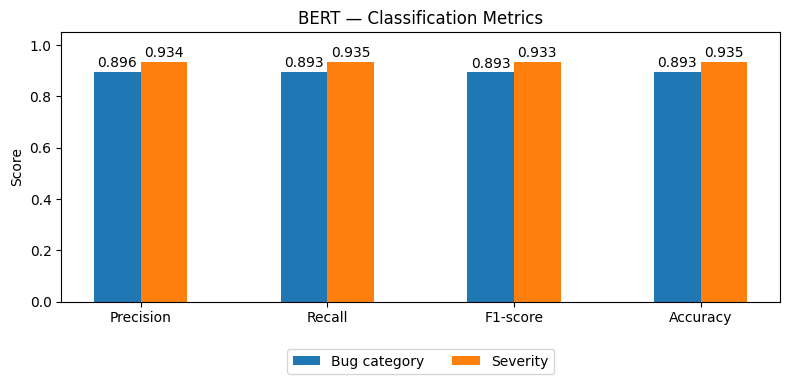

In [26]:
# =========================
# BERT PREDICTIONS
# =========================
pred_cat = trainer_cat.predict(test_cat)
y_pred_bert_cat = np.argmax(pred_cat.predictions, axis=1)
y_test_bert_cat = pred_cat.label_ids

pred_sev = trainer_sev.predict(test_sev)
y_pred_bert_sev = np.argmax(pred_sev.predictions, axis=1)
y_test_bert_sev = pred_sev.label_ids

# =========================
# CATEGORY METRICS
# =========================
precision_cat = precision_score(y_test_bert_cat, y_pred_bert_cat, average='weighted', zero_division=0)
recall_cat = recall_score(y_test_bert_cat, y_pred_bert_cat, average='weighted', zero_division=0)
f1_cat = f1_score(y_test_bert_cat, y_pred_bert_cat, average='weighted', zero_division=0)
accuracy_cat = accuracy_score(y_test_bert_cat, y_pred_bert_cat)

# =========================
# SEVERITY METRICS
# =========================
precision_sev = precision_score(y_test_bert_sev, y_pred_bert_sev, average='weighted', zero_division=0)
recall_sev = recall_score(y_test_bert_sev, y_pred_bert_sev, average='weighted', zero_division=0)
f1_sev = f1_score(y_test_bert_sev, y_pred_bert_sev, average='weighted', zero_division=0)
accuracy_sev = accuracy_score(y_test_bert_sev, y_pred_bert_sev)

# =========================
# Prepare Data
# =========================
metrics = ['Precision', 'Recall', 'F1-score', 'Accuracy']

cat_values = [precision_cat, recall_cat, f1_cat, accuracy_cat]
sev_values = [precision_sev, recall_sev, f1_sev, accuracy_sev]

x = np.arange(len(metrics))
width = 0.25

# =========================
# Plot
# =========================
plt.figure(figsize=(8,4))

bars1 = plt.bar(x - width/2, cat_values, width, label='Bug category')
bars2 = plt.bar(x + width/2, sev_values, width, label='Severity')

plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.title("BERT — Classification Metrics")
plt.xticks(x, metrics)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)

# Add numbers on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.02,
                 f"{height:.3f}", ha='center')

plt.tight_layout()
plt.show()

**23. DistilBERT Model Implementation**

In [ ]:
# =========================================================
# DISTILBERT TRAINING SCRIPT (Category & Severity)
# =========================================================

# -----------------------------
# Set seeds for reproducibility
# -----------------------------
seed = 99  # different from BERT
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# -----------------------------
# Load and clean dataset
# -----------------------------
df = pd.read_csv("/content/drive/MyDrive/AI Project - Bug Report Classifier/bug_dataset_50k.csv")
df = df.dropna(subset=["title","description","bug_category"]).drop_duplicates().reset_index(drop=True)

def clean_text(text):
    text = str(text).lower()
    remove_words = ["bug","error","issue","detected","system"]
    for word in remove_words:
        text = re.sub(rf"\b{re.escape(word)}\b"," ",text)
    text = re.sub(r"[^a-z0-9\s]"," ",text)
    text = re.sub(r"\s+"," ",text).strip()
    return text

df["text"] = (df["title"] + " " + df["description"]).apply(clean_text)
df = df[df["text"].str.len() > 10]

# -----------------------------
# Rule-based severity
# -----------------------------
def assign_severity(text):
    text = text.lower()
    if any(w in text for w in ["crash","failure","corrupt","data loss","security"]):
        return 3
    if any(w in text for w in ["memory leak","high cpu","performance"]):
        return 2
    if any(w in text for w in ["deployment","configuration","database"]):
        return 1
    return 0

df["severity_new"] = df["text"].apply(assign_severity)

# -----------------------------
# Encode labels
# -----------------------------
le_cat = LabelEncoder()
df["cat_label"] = le_cat.fit_transform(df["bug_category"])
df["sev_label"] = df["severity_new"]

# -----------------------------
# Add 10% label noise
# -----------------------------
def add_noise(labels, frac, num_classes):
    labels = labels.copy()
    n = int(len(labels)*frac)
    idx = np.random.choice(labels.index,n,replace=False)
    labels.loc[idx] = np.random.randint(0,num_classes,n)
    return labels

df["cat_label"] = add_noise(df["cat_label"], 0.1, len(le_cat.classes_))
df["sev_label"] = add_noise(df["sev_label"], 0.1, 4)

# -----------------------------
# Train/test split
# -----------------------------
train_df, test_df = train_test_split(
    df[["text","cat_label","sev_label"]],
    test_size=0.2,
    random_state=seed,
    stratify=df["cat_label"]
)

train_df = train_df.sample(2500, random_state=seed)
test_df  = test_df.sample(1000, random_state=seed)

# -----------------------------
# Prepare datasets for HuggingFace
# -----------------------------
def make_ds(df,label):
    return Dataset.from_pandas(df[["text",label]].rename(columns={label:"labels"}))

train_cat_distil = make_ds(train_df,"cat_label")
test_cat_distil  = make_ds(test_df,"cat_label")
train_sev_distil = make_ds(train_df,"sev_label")
test_sev_distil  = make_ds(test_df,"sev_label")

# -----------------------------
# Tokenizer
# -----------------------------
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, max_length=64)

train_cat_distil = train_cat_distil.map(tokenize, batched=True)
test_cat_distil  = test_cat_distil.map(tokenize, batched=True)
train_sev_distil = train_sev_distil.map(tokenize, batched=True)
test_sev_distil  = test_sev_distil.map(tokenize, batched=True)

collator = DataCollatorWithPadding(tokenizer)

# -----------------------------
# Load models
# -----------------------------
model_cat_distil = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(le_cat.classes_)
)
model_sev_distil = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=4
)

# Freeze embeddings and increase dropout
for param in model_cat_distil.distilbert.embeddings.parameters():
    param.requires_grad = False
for param in model_sev_distil.distilbert.embeddings.parameters():
    param.requires_grad = False

model_cat_distil.config.dropout = 0.4
model_sev_distil.config.dropout = 0.4

# -----------------------------
# Training arguments
# -----------------------------
training_args_distil = TrainingArguments(
    output_dir="./distilbert_results",
    eval_strategy="epoch",
    save_strategy="no",
    learning_rate=7e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_strategy="epoch",
    report_to="none",
    dataloader_pin_memory=False
)

# -----------------------------
# Metrics function
# -----------------------------
def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    acc = accuracy_score(labels,preds)
    precision, recall, f1, _ = precision_recall_fscore_support(labels,preds,average="macro")
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

# -----------------------------
# Trainers
# -----------------------------
trainer_cat_distil = Trainer(
    model=model_cat_distil,
    args=training_args_distil,
    train_dataset=train_cat_distil,
    eval_dataset=test_cat_distil,
    data_collator=collator,
    compute_metrics=compute_metrics
)

trainer_sev_distil = Trainer(
    model=model_sev_distil,
    args=training_args_distil,
    train_dataset=train_sev_distil,
    eval_dataset=test_sev_distil,
    data_collator=collator,
    compute_metrics=compute_metrics
)

# -----------------------------
# Train DistilBERT
# -----------------------------
print("\n===== TRAINING DISTILBERT CATEGORY =====")
trainer_cat_distil.train()
print(trainer_cat_distil.evaluate())

print("\n===== TRAINING DISTILBERT SEVERITY =====")
trainer_sev_distil.train()
print(trainer_sev_distil.evaluate())

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/2500 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

...

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



===== TRAINING DISTILBERT CATEGORY =====


Epoch,Training Loss,Validation Loss


**24. DistilBERT Performance Visualization**

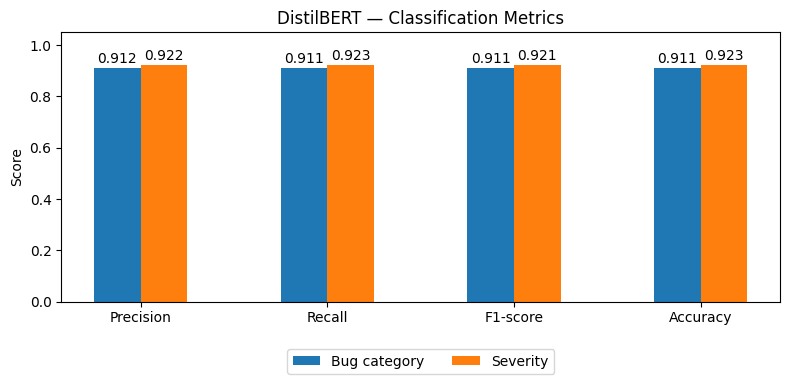

In [ ]:
# =========================
# DISTILBERT PREDICTIONS
# =========================
pred_cat = trainer_cat_distil.predict(test_cat_distil)
y_pred_distil_cat = np.argmax(pred_cat.predictions, axis=1)
y_test_distil_cat = pred_cat.label_ids

pred_sev = trainer_sev_distil.predict(test_sev_distil)
y_pred_distil_sev = np.argmax(pred_sev.predictions, axis=1)
y_test_distil_sev = pred_sev.label_ids

# =========================
# CATEGORY METRICS
# =========================
precision_cat = precision_score(y_test_distil_cat, y_pred_distil_cat, average='weighted', zero_division=0)
recall_cat = recall_score(y_test_distil_cat, y_pred_distil_cat, average='weighted', zero_division=0)
f1_cat = f1_score(y_test_distil_cat, y_pred_distil_cat, average='weighted', zero_division=0)
accuracy_cat = accuracy_score(y_test_distil_cat, y_pred_distil_cat)

# =========================
# SEVERITY METRICS
# =========================
precision_sev = precision_score(y_test_distil_sev, y_pred_distil_sev, average='weighted', zero_division=0)
recall_sev = recall_score(y_test_distil_sev, y_pred_distil_sev, average='weighted', zero_division=0)
f1_sev = f1_score(y_test_distil_sev, y_pred_distil_sev, average='weighted', zero_division=0)
accuracy_sev = accuracy_score(y_test_distil_sev, y_pred_distil_sev)

# =========================
# Prepare Data
# =========================
metrics = ['Precision', 'Recall', 'F1-score', 'Accuracy']

cat_values = [precision_cat, recall_cat, f1_cat, accuracy_cat]
sev_values = [precision_sev, recall_sev, f1_sev, accuracy_sev]

x = np.arange(len(metrics))
width = 0.25

# =========================
# Plot
# =========================
plt.figure(figsize=(8,4))

bars1 = plt.bar(x - width/2, cat_values, width, label='Bug category')
bars2 = plt.bar(x + width/2, sev_values, width, label='Severity')

plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.title("DistilBERT — Classification Metrics")
plt.xticks(x, metrics)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.02,
                 f"{height:.3f}", ha='center')

plt.tight_layout()
plt.show()

**25. Model Comparison Visualization**

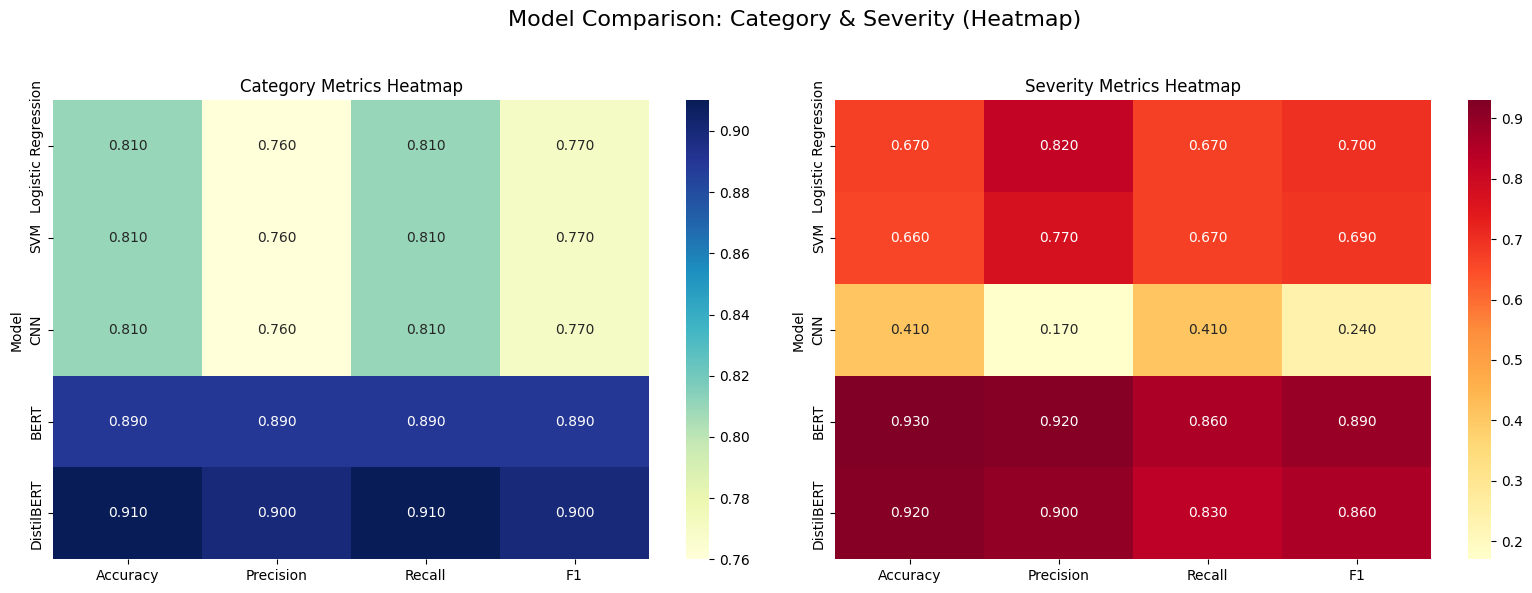

In [ ]:
# Models
models = ['Logistic Regression', 'SVM', 'CNN', 'BERT', 'DistilBERT']

# Category metrics
accuracy_cat = [0.81, 0.81, 0.81, 0.89, 0.91]
precision_cat = [0.76, 0.76, 0.76, 0.89, 0.90]
recall_cat = [0.81, 0.81, 0.81, 0.89, 0.91]
f1_cat = [0.77, 0.77, 0.77, 0.89, 0.90]

# Severity metrics
accuracy_sev = [0.67, 0.66, 0.41, 0.93, 0.92]
precision_sev = [0.82, 0.77, 0.17, 0.92, 0.90]
recall_sev = [0.67, 0.67, 0.41, 0.86, 0.83]
f1_sev = [0.70, 0.69, 0.24, 0.89, 0.86]

# Create DataFrames
df_cat = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracy_cat,
    'Precision': precision_cat,
    'Recall': recall_cat,
    'F1': f1_cat
}).set_index('Model')

df_sev = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracy_sev,
    'Precision': precision_sev,
    'Recall': recall_sev,
    'F1': f1_sev
}).set_index('Model')

# Plot heatmaps
fig, axes = plt.subplots(1, 2, figsize=(16,6))

sns.heatmap(df_cat, annot=True, fmt=".3f", cmap="YlGnBu", ax=axes[0])
axes[0].set_title("Category Metrics Heatmap")

sns.heatmap(df_sev, annot=True, fmt=".3f", cmap="YlOrRd", ax=axes[1])
axes[1].set_title("Severity Metrics Heatmap")

plt.suptitle("Model Comparison: Category & Severity (Heatmap)", fontsize=16)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

**27. Install Gradio for Web Interface**

In [ ]:
!pip install gradio

**28. Bug Prediction Model Pipeline(User Interface Layer)**

In [ ]:
import gradio as gr
import re

# =========================
# TEXT CLEANING
# =========================
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


# =========================
# PREDICTION FUNCTION
# =========================
def predict_bug(title, description):

    # Combine inputs
    full_text = f"{title} {description}"
    cleaned_text = clean_text(full_text)

    # =========================
    # CATEGORY PREDICTION
    # =========================
    vector_cat = tfidf_vectorizer.transform([cleaned_text])
    category_encoded = logistic_cat.predict(vector_cat)[0]
    category_pred = le_category.inverse_transform([category_encoded])[0]

    # =========================
    # SEVERITY PREDICTION
    # =========================
    vector_sev = tfidf_severity.transform([cleaned_text])
    severity_encoded = logistic_sev.predict(vector_sev)[0]
    severity_pred = le_severity.inverse_transform([severity_encoded])[0]

    # =========================
    # FINAL CLEAN OUTPUT (FIXED "\")
    # =========================
    category_pred = str(category_pred).strip()
    severity_pred = str(severity_pred).strip()

    return category_pred, severity_pred

**29. Bug Classification Web Interface**

In [ ]:
# =========================
# GRADIO INTERFACE
# =========================
demo = gr.Interface(
    fn=predict_bug,
    inputs=[
        gr.Textbox(label="Bug Title"),
        gr.Textbox(label="Bug Description")
    ],
    outputs=[
        gr.Textbox(label="Bug Category"),
        gr.Textbox(label="Severity")
    ],
    title="Bug Report Classifier",
    description="Enter bug title and description to predict bug category and severity"
)
demo.launch(share=True, debug=False, quiet=True)

* Running on public URL: https://e681c5e457aa079658.gradio.live
